In [2]:
#############################이전 프로젝트에 썼던 코드################################
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm  # 폰트 관리

!apt-get update -qq         # apt-get 패키지 설치 명령어, -qq : 에러외 메세지 숨기기
!apt-get install fonts-nanum* -qq #나눔글꼴 설치

fe = fm.FontEntry(fname=r'/usr/share/fonts/truetype/nanum/NanumGothic.ttf', name='NanumGothic') #파일 저장되어있는 경로와 이름 설정
fm.fontManager.ttflist.insert(0, fe)  # Matplotlib에 폰트 추가
plt.rcParams.update({'font.size': 10, 'font.family': 'NanumGothic'}) #폰트설정

'apt-get'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'apt-get'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


In [3]:
# 한글 폰트 설정
plt.rcParams['font.family'] = 'NanumGothic'  # Windows 사용자용
plt.rcParams['axes.unicode_minus'] = False     # − 기호 깨짐 방지

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("fire_data_기상데이터모두있음.csv", encoding="utf-8-sig")


In [ ]:
# 음수 제거
df = df[df["산불진화시간"] >= 0].copy()

# IQR로 이상치 제거
Q1 = df["산불진화시간"].quantile(0.25)
Q3 = df["산불진화시간"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[(df["산불진화시간"] >= lower_bound) & (df["산불진화시간"] <= upper_bound)]


In [6]:
# 결측값 정의
missing_values = [-99.9, -999]

# 기상데이터 키워드로 열 필터
weather_keywords = ['강수', '바람', '이슬점', '증발량', '일사', '습도']
weather_cols = [col for col in df.columns if any(key in col for key in weather_keywords)]

# 결측률 계산
missing_ratios = {
    col: df[col].isin(missing_values).sum() / len(df)
    for col in weather_cols
}

# 결측률 30% 미만 열만 유지
valid_weather_cols = [col for col, ratio in missing_ratios.items() if ratio < 0.3]


In [7]:
# 결측치 NaN으로 대체
df[valid_weather_cols] = df[valid_weather_cols].replace(missing_values, np.nan)

# 선형 보간 (양방향)
df[valid_weather_cols] = df[valid_weather_cols].interpolate(method='linear', limit_direction='both')


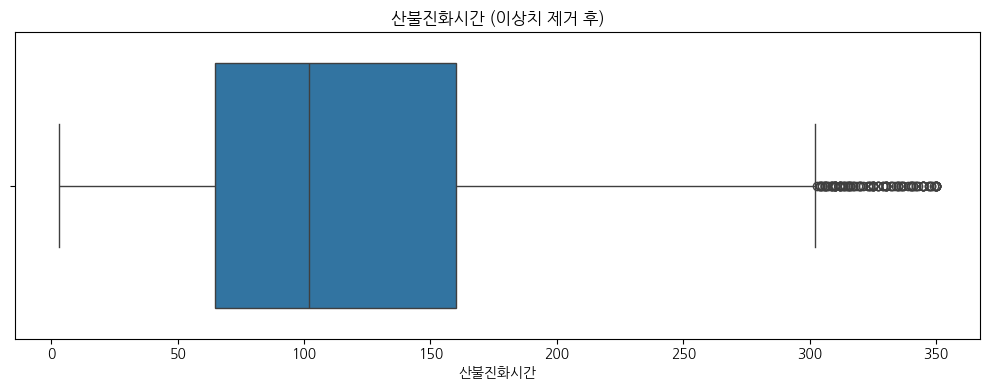

In [8]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=df, x="산불진화시간")
plt.title("산불진화시간 (이상치 제거 후)")
plt.tight_layout()
plt.show()


In [9]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
df = pd.read_csv("fire_data_기상데이터모두있음.csv", encoding="utf-8-sig")


In [10]:
# 날짜 형식 변환
df['산불발생시간'] = pd.to_datetime(df['산불발생시간'], errors='coerce')

# 음수 진화시간 제거
df = df[df['산불진화시간'] >= 0].copy()

# 이상치 제거 (IQR)
Q1, Q3 = df['산불진화시간'].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df['산불진화시간'] >= lower) & (df['산불진화시간'] <= upper)]


In [11]:
# -99.9, -999 → NaN
df.replace([-99.9, -999], np.nan, inplace=True)

# 사용할 열 목록
features = [
    '피해면적', 'ALTD_강수', 'RN_MAX_1HR_OCUR_TMA_강수', 'RN_MAX_10M_OCUR_TMA_강수',
    'ALTD_바람', 'WS_DAVG_바람', 'WS_INS_MAX_바람', 'WS_INS_MAX_OCUR_TMA_바람',
    'WD_INS_MAX_바람', 'WS_MAX_바람', 'WS_MAX_OCUR_TMA_바람', 'WD_MAX_바람',
    'WD_FRQ_바람', 'WS_MIX_바람', 'WD_MIX_바람', 'ALTD_이슬점', 'TD_AVG_이슬점',
    'TD_MAX_이슬점', 'TD_MAX_OCUR_TMA_이슬점', 'TD_MIN_이슬점', 'TD_MIN_OCUR_TMA_이슬점',
    'ALTD_증발량', 'ALTD_일사', 'SI_HR1_MAX_OCUR_TMA_일사'
]

# 결측치 있는 행 제거
df = df.dropna(subset=features + ['산불진화시간', '산불발생시간'])


In [ ]:
def make_Xy_weighted_recent_strong(target, prev, feat, strength=5):
    X, y = [], []
    
    # 최근일일수록 가중치 ↑ (지수적으로 증가)
    weights = np.exp(np.linspace(0, strength, 14))  
    weights = weights / weights.max()               

    for i in range(len(target)):
        s, e = i*14, (i+1)*14
        if e <= len(prev):
            seq = prev.iloc[s:e][feat].values
            if seq.shape == (14, len(feat)):
                seq_weighted = seq * weights[:, None]
                X.append(seq_weighted)
                y.append(target.loc[i, '산불진화시간'])
    return np.array(X), np.array(y)


In [ ]:
# 1. target (산불 발생 시점) 과 prev (14일치 시계열 데이터) 구분
target_rows = df[df['산불_이전14일데이터'] != 1].reset_index(drop=True)
prev_rows   = df[df['산불_이전14일데이터'] == 1].reset_index(drop=True)

# 2. 연도 분리
target_rows['발생연도'] = pd.to_datetime(target_rows['산불발생시간']).dt.year
train_t = target_rows[target_rows['발생연도'] <= 2022].reset_index(drop=True)
test_t  = target_rows[target_rows['발생연도'] == 2023].reset_index(drop=True)

# 3. 함수 적용
X_train, y_train = make_Xy_weighted_recent_strong(train_t, prev_rows, features)
X_test,  y_test  = make_Xy_weighted_recent_strong(test_t,  prev_rows, features)


In [ ]:

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

X_train_scaled = scaler_x.fit_transform(X_train)
X_test_scaled = scaler_x.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

# LSTM 입력 형태로 변환
X_train_lstm = X_train_scaled.reshape(-1, 1, X_train_scaled.shape[1])
X_test_lstm = X_test_scaled.reshape(-1, 1, X_test_scaled.shape[1])

In [14]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, input_shape=(1, X_train.shape[1])),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.fit(X_train_lstm, y_train_scaled, epochs=100, batch_size=32, verbose=1)


Epoch 1/100


C:\Users\endor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 891us/step - loss: 0.0580 
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 812us/step - loss: 0.0393
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 793us/step - loss: 0.0372
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 792us/step - loss: 0.0359
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - loss: 0.0361
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 778us/step - loss: 0.0376
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - loss: 0.0375
Epoch 8/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 802us/step - loss: 0.0345
Epoch 9/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - loss: 0.0340
Epoch 10/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 797us/step - loss: 0.0343
Epoch 11/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 828us/step - loss: 0.0350
Epoch 12/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - loss: 0.0332
Epoch 13/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 788us/step - loss: 0.0337
Epoch 14/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 808us/step - loss: 0.0337
Epoch 15/100
104/104 ━━━━━

In [15]:
# 예측
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# R² 점수
r2 = r2_score(y_test, y_pred)
print("R² 점수:", r2)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
R² 점수: 0.2506378532270459


In [18]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, X_train.shape[1])),

    # 1. 첫 번째 LSTM 층 (시퀀스를 유지하며 다음 층으로 넘김)
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dropout(0.3),  # 과적합 방지용

    # 2. 두 번째 LSTM 층 (출력만)
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dropout(0.3),

    # 3. Fully connected layer
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])


In [19]:
model.compile(optimizer='adam', loss='mse')
model.fit(X_train_lstm, y_train_scaled, epochs=100, batch_size=32, verbose=1)


Epoch 1/100


104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.0674
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0416 
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0408  
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0372  
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0391  
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0365  
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0365  
Epoch 8/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0367  
Epoch 9/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0402  
Epoch 10/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0389  
Epoch 11/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0374
Epoch 12/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0373  
Epoch 13/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0368
Epoch 14/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0340  
Epoch 15/100
104/104 ━━━━━━━━━━━━━

In [20]:
# 예측
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# R² 점수
r2 = r2_score(y_test, y_pred)
print("R² 점수:", r2)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
R² 점수: 0.337576004218748


In [21]:
import tensorflow as tf
from sklearn.metrics import r2_score
import numpy as np

best_r2 = -np.inf
target_r2 = 0.4
attempt = 0

while best_r2 < target_r2:
    attempt += 1
    print(f"\n🚀 [시도 {attempt}] 모델을 학습합니다...")

    # 모델 정의
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(1, X_train.shape[1])),
        tf.keras.layers.LSTM(64, return_sequences=True),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.LSTM(32),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dense(1)
    ])

    model.compile(optimizer='adam', loss='mse')
    model.fit(X_train_lstm, y_train_scaled, epochs=100, batch_size=32, verbose=0)

    # 예측 및 R² 계산
    y_pred_scaled = model.predict(X_test_lstm, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled)
    r2 = r2_score(y_test, y_pred)

    print(f"📈 R² = {r2:.4f}")

    if r2 > best_r2:
        best_r2 = r2
        # 필요시 모델 저장
        model.save(f"best_lstm_r2_{best_r2:.4f}.h5")
        print(f"✅ 새로운 최고 성능! 모델 저장 완료.")

print(f"\n🎉 학습 완료! 최종 R² = {best_r2:.4f} 이상 달성됨.")



🚀 [시도 1] 모델을 학습합니다...


📈 R² = 0.3129
✅ 새로운 최고 성능! 모델 저장 완료.

🚀 [시도 2] 모델을 학습합니다...
📈 R² = 0.3074

🚀 [시도 3] 모델을 학습합니다...


📈 R² = 0.3174
✅ 새로운 최고 성능! 모델 저장 완료.

🚀 [시도 4] 모델을 학습합니다...


📈 R² = 0.3226
✅ 새로운 최고 성능! 모델 저장 완료.

🚀 [시도 5] 모델을 학습합니다...


📈 R² = 0.3422
✅ 새로운 최고 성능! 모델 저장 완료.

🚀 [시도 6] 모델을 학습합니다...
📈 R² = 0.2917

🚀 [시도 7] 모델을 학습합니다...
📈 R² = 0.3191

🚀 [시도 8] 모델을 학습합니다...
📈 R² = 0.3227

🚀 [시도 9] 모델을 학습합니다...
📈 R² = 0.3246

🚀 [시도 10] 모델을 학습합니다...
📈 R² = 0.3075

🚀 [시도 11] 모델을 학습합니다...
📈 R² = 0.3175

🚀 [시도 12] 모델을 학습합니다...
📈 R² = 0.3214

🚀 [시도 13] 모델을 학습합니다...
📈 R² = 0.2745

🚀 [시도 14] 모델을 학습합니다...
📈 R² = 0.3213

🚀 [시도 15] 모델을 학습합니다...
📈 R² = 0.3264

🚀 [시도 16] 모델을 학습합니다...
📈 R² = 0.3107

🚀 [시도 17] 모델을 학습합니다...
📈 R² = 0.3350

🚀 [시도 18] 모델을 학습합니다...
📈 R² = 0.3305

🚀 [시도 19] 모델을 학습합니다...
📈 R² = 0.3052

🚀 [시도 20] 모델을 학습합니다...
📈 R² = 0.2962

🚀 [시도 21] 모델을 학습합니다...
📈 R² = 0.3141

🚀 [시도 22] 모델을 학습합니다...
📈 R² = 0.3172

🚀 [시도 23] 모델을 학습합니다...
📈 R² = 0.3238

🚀 [시도 24] 모델을 학습합니다...
📈 R² = 0.3239

🚀 [시도 25] 모델을 학습합니다...


...

📈 R² = 0.3477
✅ 새로운 최고 성능! 모델 저장 완료.

🚀 [시도 142] 모델을 학습합니다...
📈 R² = 0.3383

🚀 [시도 143] 모델을 학습합니다...
📈 R² = 0.2883

🚀 [시도 144] 모델을 학습합니다...
📈 R² = 0.3368

🚀 [시도 145] 모델을 학습합니다...
📈 R² = 0.2977

🚀 [시도 146] 모델을 학습합니다...
📈 R² = 0.3044

🚀 [시도 147] 모델을 학습합니다...
📈 R² = 0.3213

🚀 [시도 148] 모델을 학습합니다...
📈 R² = 0.3419

🚀 [시도 149] 모델을 학습합니다...
📈 R² = 0.3386

🚀 [시도 150] 모델을 학습합니다...
📈 R² = 0.3070

🚀 [시도 151] 모델을 학습합니다...
📈 R² = 0.3261

🚀 [시도 152] 모델을 학습합니다...
📈 R² = 0.3319

🚀 [시도 153] 모델을 학습합니다...
📈 R² = 0.3237

🚀 [시도 154] 모델을 학습합니다...
📈 R² = 0.3383

🚀 [시도 155] 모델을 학습합니다...
📈 R² = 0.3058

🚀 [시도 156] 모델을 학습합니다...
📈 R² = 0.3315

🚀 [시도 157] 모델을 학습합니다...
📈 R² = 0.3373

🚀 [시도 158] 모델을 학습합니다...
📈 R² = 0.3438

🚀 [시도 159] 모델을 학습합니다...
📈 R² = 0.3251

🚀 [시도 160] 모델을 학습합니다...
📈 R² = 0.3174

🚀 [시도 161] 모델을 학습합니다...
📈 R² = 0.3409

🚀 [시도 162] 모델을 학습합니다...
📈 R² = 0.2701

🚀 [시도 163] 모델을 학습합니다...
📈 R² = 0.3312

🚀 [시도 164] 모델을 학습합니다...
📈 R² = 0.3278

🚀 [시도 165] 모델을 학습합니다...
📈 R² = 0.3157

🚀 [시도 166] 모델을 학습합니다...
📈 

📈 R² = 0.3493
✅ 새로운 최고 성능! 모델 저장 완료.

🚀 [시도 215] 모델을 학습합니다...
📈 R² = 0.3255

🚀 [시도 216] 모델을 학습합니다...
📈 R² = 0.2957

🚀 [시도 217] 모델을 학습합니다...
📈 R² = 0.3430

🚀 [시도 218] 모델을 학습합니다...
📈 R² = 0.3315

🚀 [시도 219] 모델을 학습합니다...
📈 R² = 0.3232

🚀 [시도 220] 모델을 학습합니다...
📈 R² = 0.3189

🚀 [시도 221] 모델을 학습합니다...
📈 R² = 0.3310

🚀 [시도 222] 모델을 학습합니다...
📈 R² = 0.3328

🚀 [시도 223] 모델을 학습합니다...
📈 R² = 0.3031

🚀 [시도 224] 모델을 학습합니다...
📈 R² = 0.2855

🚀 [시도 225] 모델을 학습합니다...
📈 R² = 0.3113

🚀 [시도 226] 모델을 학습합니다...
📈 R² = 0.3119

🚀 [시도 227] 모델을 학습합니다...
📈 R² = 0.3354

🚀 [시도 228] 모델을 학습합니다...
📈 R² = 0.3282

🚀 [시도 229] 모델을 학습합니다...
📈 R² = 0.2975

🚀 [시도 230] 모델을 학습합니다...
📈 R² = 0.3242

🚀 [시도 231] 모델을 학습합니다...
📈 R² = 0.2679

🚀 [시도 232] 모델을 학습합니다...
📈 R² = 0.3306

🚀 [시도 233] 모델을 학습합니다...
📈 R² = 0.3352

🚀 [시도 234] 모델을 학습합니다...
📈 R² = 0.3152

🚀 [시도 235] 모델을 학습합니다...
📈 R² = 0.3384

🚀 [시도 236] 모델을 학습합니다...
📈 R² = 0.2843

🚀 [시도 237] 모델을 학습합니다...
📈 R² = 0.3236

🚀 [시도 238] 모델을 학습합니다...
📈 R² = 0.2835

🚀 [시도 239] 모델을 학습합니다...
📈 

📈 R² = 0.3495
✅ 새로운 최고 성능! 모델 저장 완료.

🚀 [시도 369] 모델을 학습합니다...
📈 R² = 0.2603

🚀 [시도 370] 모델을 학습합니다...
📈 R² = 0.3051

🚀 [시도 371] 모델을 학습합니다...
📈 R² = 0.3228

🚀 [시도 372] 모델을 학습합니다...
📈 R² = 0.2367

🚀 [시도 373] 모델을 학습합니다...
📈 R² = 0.3304

🚀 [시도 374] 모델을 학습합니다...
📈 R² = 0.3262

🚀 [시도 375] 모델을 학습합니다...
📈 R² = 0.3247

🚀 [시도 376] 모델을 학습합니다...
📈 R² = 0.3312

🚀 [시도 377] 모델을 학습합니다...
📈 R² = 0.3102

🚀 [시도 378] 모델을 학습합니다...
📈 R² = 0.3182

🚀 [시도 379] 모델을 학습합니다...
📈 R² = 0.3402

🚀 [시도 380] 모델을 학습합니다...
📈 R² = 0.3364

🚀 [시도 381] 모델을 학습합니다...
📈 R² = 0.3306

🚀 [시도 382] 모델을 학습합니다...
📈 R² = 0.3302

🚀 [시도 383] 모델을 학습합니다...
📈 R² = 0.3371

🚀 [시도 384] 모델을 학습합니다...
📈 R² = 0.3271

🚀 [시도 385] 모델을 학습합니다...
📈 R² = 0.3168

🚀 [시도 386] 모델을 학습합니다...
📈 R² = 0.3345

🚀 [시도 387] 모델을 학습합니다...
📈 R² = 0.3295

🚀 [시도 388] 모델을 학습합니다...
📈 R² = 0.3283

🚀 [시도 389] 모델을 학습합니다...
📈 R² = 0.3371

🚀 [시도 390] 모델을 학습합니다...
📈 R² = 0.2993

🚀 [시도 391] 모델을 학습합니다...
📈 R² = 0.3216

🚀 [시도 392] 모델을 학습합니다...
📈 R² = 0.3405

🚀 [시도 393] 모델을 학습합니다...
📈 

📈 R² = 0.3496
✅ 새로운 최고 성능! 모델 저장 완료.

🚀 [시도 1325] 모델을 학습합니다...
📈 R² = 0.3198

🚀 [시도 1326] 모델을 학습합니다...
📈 R² = 0.3245

🚀 [시도 1327] 모델을 학습합니다...
📈 R² = 0.3367

🚀 [시도 1328] 모델을 학습합니다...
📈 R² = 0.3355

🚀 [시도 1329] 모델을 학습합니다...
📈 R² = 0.3316

🚀 [시도 1330] 모델을 학습합니다...
📈 R² = 0.3087

🚀 [시도 1331] 모델을 학습합니다...
📈 R² = 0.3098

🚀 [시도 1332] 모델을 학습합니다...
📈 R² = 0.3294

🚀 [시도 1333] 모델을 학습합니다...
📈 R² = 0.3244

🚀 [시도 1334] 모델을 학습합니다...
📈 R² = 0.3301

🚀 [시도 1335] 모델을 학습합니다...
📈 R² = 0.3341

🚀 [시도 1336] 모델을 학습합니다...
📈 R² = 0.2768

🚀 [시도 1337] 모델을 학습합니다...
📈 R² = 0.3289

🚀 [시도 1338] 모델을 학습합니다...
📈 R² = 0.2799

🚀 [시도 1339] 모델을 학습합니다...
📈 R² = 0.3311

🚀 [시도 1340] 모델을 학습합니다...
📈 R² = 0.3230

🚀 [시도 1341] 모델을 학습합니다...
📈 R² = 0.3199

🚀 [시도 1342] 모델을 학습합니다...
📈 R² = 0.3322

🚀 [시도 1343] 모델을 학습합니다...
📈 R² = 0.3072

🚀 [시도 1344] 모델을 학습합니다...
📈 R² = 0.3216

🚀 [시도 1345] 모델을 학습합니다...
📈 R² = 0.3124

🚀 [시도 1346] 모델을 학습합니다...
📈 R² = 0.3449

🚀 [시도 1347] 모델을 학습합니다...
📈 R² = 0.3198

🚀 [시도 1348] 모델을 학습합니다...
📈 R² = 0.3275

🚀 

KeyboardInterrupt: 

In [28]:
from tensorflow.keras.layers import Bidirectional

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, X_train.shape[1])),
    Bidirectional(tf.keras.layers.LSTM(128, return_sequences=True)),
    tf.keras.layers.Dropout(0.4),
    Bidirectional(tf.keras.layers.LSTM(64)),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train_lstm, y_train_scaled, epochs=100, batch_size=32, verbose=1)


Epoch 1/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0607
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0396
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0392
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0380
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0399
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0391
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0366
Epoch 8/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0388
Epoch 9/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0360
Epoch 10/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0363
Epoch 11/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0353
Epoch 12/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0361
Epoch 13/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0361
Epoch 14/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0330
Epoch 15/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0

In [27]:
# 예측
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# R² 점수
r2 = r2_score(y_test, y_pred)
print("R² 점수:", r2)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
R² 점수: 0.27362879166663434


In [29]:
from tensorflow.keras.layers import LayerNormalization, LeakyReLU

model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(1, X_train.shape[1])),
    tf.keras.layers.LSTM(128, return_sequences=True),
    LayerNormalization(),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(64),
    LeakyReLU(alpha=0.1),
    tf.keras.layers.Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train_lstm, y_train_scaled, epochs=100, batch_size=32, verbose=1)

Epoch 1/100


C:\Users\endor\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0465
Epoch 2/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0387
Epoch 3/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0383
Epoch 4/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0340
Epoch 5/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0364
Epoch 6/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0349
Epoch 7/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0349
Epoch 8/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0308
Epoch 9/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0344
Epoch 10/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0330
Epoch 11/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0302
Epoch 12/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0327
Epoch 13/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0320
Epoch 14/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0308
Epoch 15/100
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

In [30]:
# 예측
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

# R² 점수
r2 = r2_score(y_test, y_pred)
print("R² 점수:", r2)


15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
R² 점수: -0.07229779457795882


In [32]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, LayerNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(1, X_train.shape[1])),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.4),
    LayerNormalization(),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1)
])

# 8. 학습 설정 및 학습
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mse')

callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
]

history = model.fit(
    X_train_lstm, y_train_scaled,
    epochs=300,
    batch_size=16,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# 9. 예측 및 평가
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

r2 = r2_score(y_test, y_pred)
print("📈 최종 R² 점수:", r2)

Epoch 1/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0874 - val_loss: 0.0454 - learning_rate: 5.0000e-04
Epoch 2/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0425 - val_loss: 0.0442 - learning_rate: 5.0000e-04
Epoch 3/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0428 - val_loss: 0.0456 - learning_rate: 5.0000e-04
Epoch 4/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0405 - val_loss: 0.0454 - learning_rate: 5.0000e-04
Epoch 5/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0384 - val_loss: 0.0448 - learning_rate: 5.0000e-04
Epoch 6/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0400 - val_loss: 0.0487 - learning_rate: 5.0000e-04
Epoch 7/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0398 - val_loss: 0.0436 - learning_rate: 5.0000e-04
Epoch 8/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0404 - val_loss: 0.0439 - learning_rate: 5.0000e-04
Epoch 9/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0390 - val_loss: 

In [17]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout, Bidirectional, LayerNormalization
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model = Sequential([
    Input(shape=(1, X_train.shape[1])),
    Bidirectional(LSTM(128, return_sequences=True)),
    Dropout(0.4),
    LayerNormalization(),
    Bidirectional(LSTM(64)),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dense(1)
])

# 8. 학습 설정 및 학습
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
model.compile(optimizer=optimizer, loss='mse')

callbacks = [
    EarlyStopping(patience=15, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
]

history = model.fit(
    X_train_lstm, y_train_scaled,
    epochs=300,
    batch_size=16,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

# 9. 예측 및 평가
y_pred_scaled = model.predict(X_test_lstm)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

r2 = r2_score(y_test, y_pred)
print("📈 최종 R² 점수:", r2)

Epoch 1/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0740 - val_loss: 0.0465 - learning_rate: 5.0000e-04
Epoch 2/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0397 - val_loss: 0.0463 - learning_rate: 5.0000e-04
Epoch 3/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0405 - val_loss: 0.0446 - learning_rate: 5.0000e-04
Epoch 4/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0405 - val_loss: 0.0461 - learning_rate: 5.0000e-04
Epoch 5/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0425 - val_loss: 0.0497 - learning_rate: 5.0000e-04
Epoch 6/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0422 - val_loss: 0.0464 - learning_rate: 5.0000e-04
Epoch 7/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0392 - val_loss: 0.0470 - learning_rate: 5.0000e-04
Epoch 8/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0375 - val_loss: 0.0429 - learning_rate: 5.0000e-04
Epoch 9/300
166/166 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0397 - val_loss: 